<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/main/Document_Processing_with_PaddleOCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dcument Processing with PaddleOCR

In [1]:
# Install all functionalities, such as document parsing, document understanding,
# document translation, and key information extraction
!pip install "paddleocr[all]"

In [2]:
# You need to install paddlepaddle superatedly appart from paddlleocr othe
# or you could just !pip install "paddleocr[all]@git+https://github.com/PaddlePaddle/PaddleOCR.git"
# Make sure the paddle version matches to paddleOCR version
!pip install paddlepaddle==3.2.0

In [3]:
# Make import superately make sure the version matches
from paddleocr import PaddleOCR

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.


In [4]:
from PIL import Image
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colormaps
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.agents import AgentExecutor
import csv

In [5]:
import os
from dotenv import load_dotenv
# Load environment variable from .env
_ = load_dotenv(override=True)

## 1. PaddleOCR Basic

In [6]:
# Initialize english OCR model
ocr = PaddleOCR(lang='en')

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached f

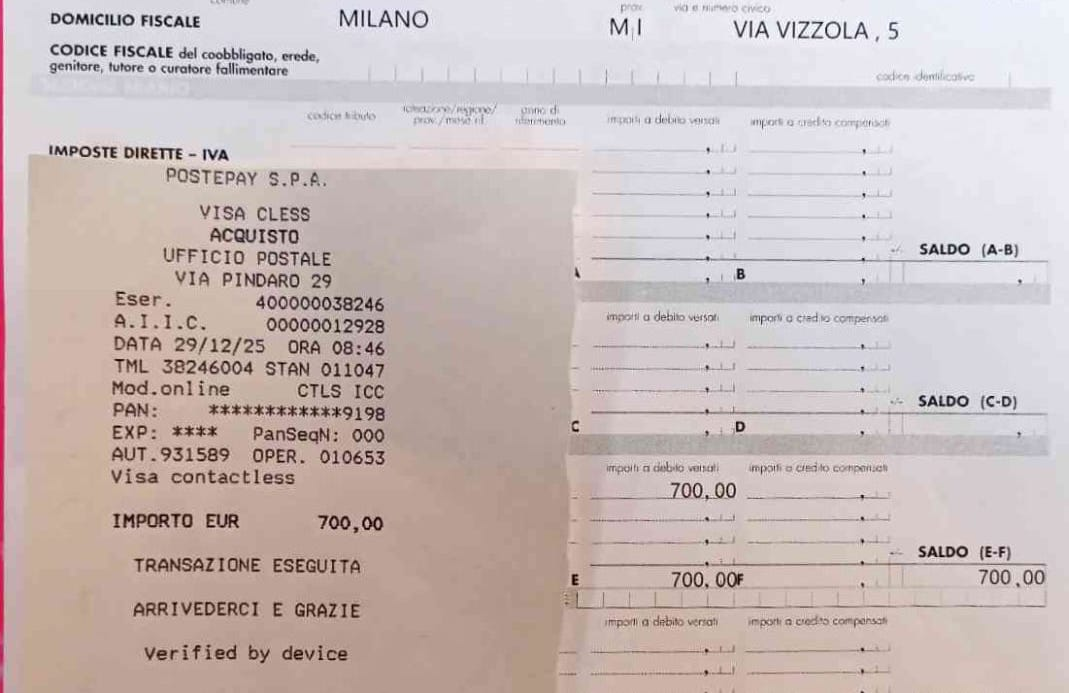

In [8]:
from IPython.display import display

image_path = '/noisy_img.jpeg'
img = Image.open(image_path)
display(img)

In [9]:
import paddleocr
import paddle

In [10]:
print("paddleocr version: ", paddleocr.__version__)
print("paddle version: ", paddle.__version__)


paddleocr version:  3.3.3
paddle version:  3.2.0


In [11]:
# Run OCR
result = ocr.predict(image_path)

In [14]:
page = result[0]
texts = page['rec_texts'] # recognized text strings
scores = page['rec_scores'] # confidence scores for each text line
boxes = page['rec_polys'] # bounding box coordinates

for text, score, box in zip(texts, scores, boxes): # zip -> ties together items with the same position
  # box is a numpy array
  coords = box.astype(int).tolist() # convert to normal list of ints
  print(f"{text:25} | {score:.3f} | {coords}")

DOMICILIO FISCALE         | 0.999 | [[21, 0], [179, 0], [179, 20], [20, 16]]
MILANO                    | 0.937 | [[331, 1], [412, 1], [412, 14], [331, 14]]
MT                        | 0.777 | [[597, 0], [642, 0], [642, 24], [597, 24]]
VIA VIZZOLA, 5            | 0.968 | [[728, 0], [905, 0], [905, 20], [728, 20]]
CODICE FISCALE del coobbligato, erede, | 0.987 | [[22, 28], [302, 34], [301, 53], [21, 48]]
genitore, tutore o curatore fallimentare | 0.982 | [[21, 47], [270, 48], [270, 68], [21, 67]]
codice demilicative       | 0.744 | [[876, 43], [991, 39], [991, 64], [877, 67]]
codice sibulo             | 0.788 | [[284, 94], [362, 94], [362, 115], [284, 115]]
(ChcUc/0/                 | 0.583 | [[383, 87], [485, 87], [485, 106], [383, 106]]
gnnod                     | 0.718 | [[504, 88], [554, 85], [555, 103], [505, 106]]
pRO/md.                   | 0.502 | [[394, 100], [477, 98], [478, 116], [394, 118]]
iommen                    | 0.482 | [[502, 101], [561, 101], [561, 115], [502, 115]]
i

In [15]:
# Preproccess the image
img = page['doc_preprocessor_res']['output_img']

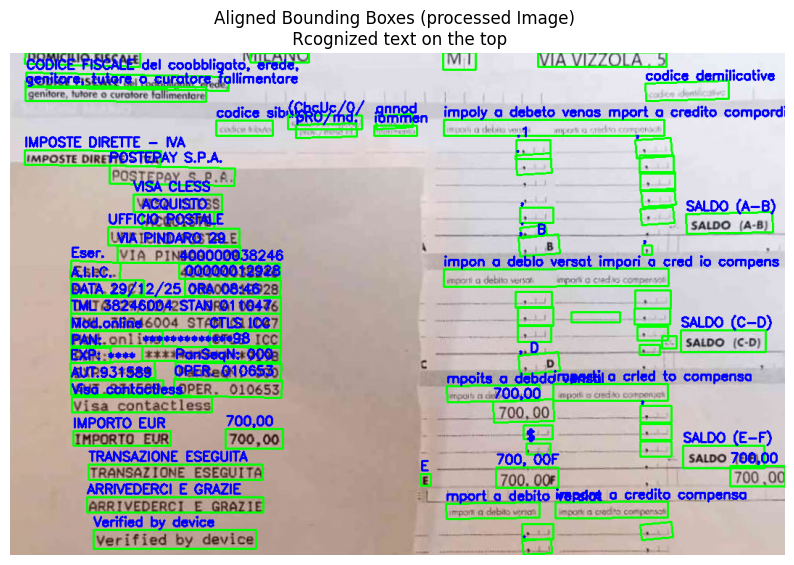

In [20]:
# display preprocessed image with all items overlayed
img_plot = img.copy()
for text, box in zip(texts, boxes):
  pts = np.array(box, dtype=int)
  cv2.polylines(img_plot, [pts], True, (0, 255, 0), 2)
  x, y = pts[0]
  cv2.putText(img_plot, text, (x, y-5),
              cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

plt.figure(figsize=(10, 16))
plt.imshow(cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Aligned Bounding Boxes (processed Image) \n Rcognized text on the top")
plt.show()

## 1.1 Create the PaddleOCR Tool
Turn PaddleOCR to a tool so that can be used with an agent

In [25]:
from langchain.tools import tool
import base64
from langchain_openai import ChatOpenAI
from typing import List, Dict, Any

@tool
def paddle_ocr_read_document(image_path: str) -> List[Dict[str, Any]]:
  """
  Reads an image from the given path and returns extracted text
  with bounding boxes.

  Returns a list of dictionaries, each containing:
  - 'text': the recognized text string
  - 'bbox': bounding box coordinates [x_min, y_min, x_max, y_max]
  - 'confidence': recognition confidence score (if available)
  """
  try:
    result = ocr.predict(image_path)
    page = result[0]

    texts = page['rec_texts']
    boxes = page['dt_polys']
    scores = page.get('rec_scores', [None] * len(texts))

    extracted_items = []
    for text, box, score in zip(texts, boxes, scores):
      x_coords = [point[0] for point in box]
      y_coords = [point[1] for point in box]
      bbox = [min(x_coords), min(y_coords), max(x_coords),
              max(y_coords)]

      item = {
          'text': text,
          'bbox': bbox
      }

      if score is not None:
        item['confidance'] = score
      extracted_items.append(item)
    return extracted_items
  except Exception as e:
    return [{'error': f'Error reading image {e}'}]

## 1.2 Create & Run the Agent


In [26]:
# 1. Define the list of tools
tools = [paddle_ocr_read_document]

# 2. Set up the OpenAI GPT model
if "OPENAI_API_KEY" not in os.environ:
    print("OPENAI_API_KEY environment variable is not set.")
    llm = None
else:
    llm = ChatOpenAI(
        model="gpt-5-mini",
        temperature=1
    )
    print("OpenAI Chat model initialized.")

OpenAI Chat model initialized.


In [30]:
from langchain.agents import create_tool_calling_agent
# 3. Create the OpenAI-compatible prompt
prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a helpful assistant designed to extract information "+
        "from documents. "
          "You have access to this tool: "
          "Paddle OCR tool to extract raw texts, bounding boxes for "+
          "each text and confidence score from images "
    ),
    ("user", "{input}"),
    MessagesPlaceholder(variable_name='agent_scratchpad'),
])

# 4. Create a proper tool-calling agent
agent = create_tool_calling_agent(llm, tools, prompt)

# 5. Set up the AgentExecutor to run the tool-enabled loop
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

In [34]:
# Run the agent and extract information
task = """
Process the document at '/noisy_img.jpeg' and evaluate that
the total amount is correct.
"""

response = agent_executor.invoke({"input": task})



> Entering new AgentExecutor chain...

Invoking: `paddle_ocr_read_document` with `{'image_path': '/noisy_img.jpeg'}`


[{'text': 'DOMICILIO FISCALE', 'bbox': [np.int16(20), np.int16(0), np.int16(179), np.int16(20)], 'confidance': 0.9993115663528442}, {'text': 'MILANO', 'bbox': [np.int16(331), np.int16(1), np.int16(412), np.int16(14)], 'confidance': 0.9368214011192322}, {'text': 'MT', 'bbox': [np.int16(597), np.int16(0), np.int16(642), np.int16(24)], 'confidance': 0.7772237062454224}, {'text': 'VIA VIZZOLA, 5', 'bbox': [np.int16(728), np.int16(0), np.int16(905), np.int16(20)], 'confidance': 0.9681915044784546}, {'text': 'CODICE FISCALE del coobbligato, erede,', 'bbox': [np.int16(21), np.int16(28), np.int16(302), np.int16(53)], 'confidance': 0.9871707558631897}, {'text': 'genitore, tutore o curatore fallimentare', 'bbox': [np.int16(21), np.int16(47), np.int16(270), np.int16(68)], 'confidance': 0.9819205403327942}, {'text': 'codice demilicative', 'bbox': [np.int16(876), np.int16(39), np